In [ ]:
#Loading dataset

In [18]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Dataset path:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset path: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
#exploring dataset structure

In [19]:
import os
base_path = "/kaggle/input/brain-tumor-mri-dataset"
os.listdir(base_path)

['Training', 'Testing']

In [20]:
train_path=os.path.join(base_path,"Training")
os.listdir(train_path)

['pituitary', 'notumor', 'meningioma', 'glioma']

In [ ]:
# Imports / paths

In [21]:
import cv2
import numpy as np

train_path="/kaggle/input/brain-tumor-mri-dataset/Training"
test_path="/kaggle/input/brain-tumor-mri-dataset/Testing"

classes= os.listdir(train_path)
print(classes)

['pituitary', 'notumor', 'meningioma', 'glioma']


In [ ]:
# Image loader function / loading training and testing data

In [22]:
import os
import cv2
import numpy as np

# Define paths for training and testing data
train_path="/kaggle/input/brain-tumor-mri-dataset/Training"
test_path="/kaggle/input/brain-tumor-mri-dataset/Testing"

# Define classes, ensuring it's available for load_images
classes=['glioma','meningioma', 'notumor', 'pituitary']

def load_images(folder_path , image_size=224):
  X= []
  y= []

  for label , class_name in enumerate(classes):
    class_folder= os.path.join(folder_path , class_name)

    if not os.path.isdir(class_folder):
      continue

    for image_name in os.listdir(class_folder):
      image_path= os.path.join(class_folder , image_name)

      if not os.path.isfile(image_path):
        continue

      image=cv2.imread(image_path)

      if image is None:
        continue

      image=cv2.resize(image , (image_size , image_size))
      image= image/128.0

      X.append(image)
      y.append(label)

  return np.array(X), np.array(y)

X_train , y_train= load_images(train_path)
X_test , y_test = load_images(test_path)

print("Training data shape:", X_train.shape)
print("Testing data shape:" , X_test.shape)

KeyboardInterrupt: 

In [ ]:
# Issue: session crashed after using all avaliable RAM
# Solution: using keras image data generator

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set paths
train_path = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_path = "/kaggle/input/brain-tumor-mri-dataset/Testing"

# Parameters
img_size = (128, 128)
batch_size = 16

# Training data generator
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'  # multiclass
)

# Testing data generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [ ]:
# Building CNN

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Dense , Dropout

num_classes= 4

model= Sequential()

# First convolution block
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D((2,2)))

# Second convolution block
model.add(Conv2D(64,(3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Third convolution blcok
model.add(Conv2D(128, (3,3) , activation= 'relu'))
model.add(MaxPooling2D(((2,2))))

# Flattening and fully connected

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes , activation='softmax'))

# Compiling model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training the model

In [25]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [26]:
epochs= 20
history= model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=epochs
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 215s 596ms/step - accuracy: 0.6141 - loss: 0.8720 - val_accuracy: 0.7857 - val_loss: 0.5253
Epoch 2/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 212s 593ms/step - accuracy: 0.8359 - loss: 0.4286 - val_accuracy: 0.8581 - val_loss: 0.3762
Epoch 3/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 217s 607ms/step - accuracy: 0.8882 - loss: 0.3161 - val_accuracy: 0.8780 - val_loss: 0.2770
Epoch 4/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 195s 545ms/step - accuracy: 0.9208 - loss: 0.2212 - val_accuracy: 0.8879 - val_loss: 0.2497
Epoch 5/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 201s 563ms/step - accuracy: 0.9319 - loss: 0.1895 - val_accuracy: 0.9260 - val_loss: 0.1897
Epoch 6/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 194s 543ms/step - accuracy: 0.9494 - loss: 0.1423 - val_accuracy: 0.9451 - val_loss: 0.1563
Epoch 7/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 195s 546ms/step - accuracy: 0.9561 - loss: 0.1188 - val_accuracy: 0.9329 - val_loss: 0.1819
Epoch 8/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 195s 547ms/step - accuracy: 0.9579 -

In [ ]:
#evaluating the model

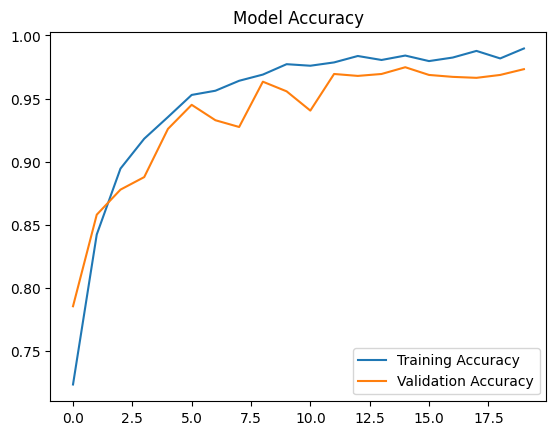

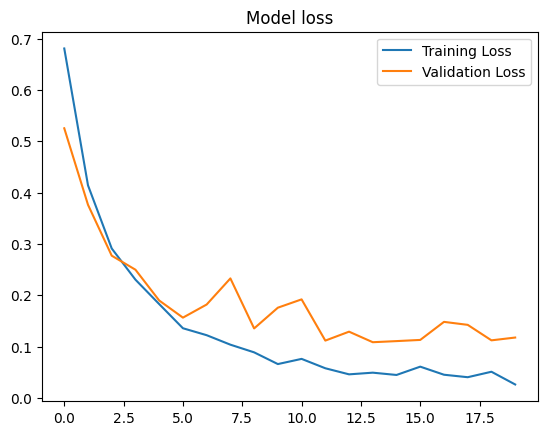

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'] , label= 'Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

plt.plot(history.history['loss'], label= 'Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model loss')
plt.show()

In [ ]:
# Confusion matrix and classification report

In [28]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=classes))

82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step
Confusion Matrix:
[[281  17   0   2]
 [  8 292   4   2]
 [  0   0 405   0]
 [  1   1   0 298]]
Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.94      0.95       300
  meningioma       0.94      0.95      0.95       306
     notumor       0.99      1.00      1.00       405
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311



In [ ]:
# Saving the model

In [29]:
model.save("brain_tumor_cnn_model.keras")

from tensorflow.keras.models import load_model
model= load_model("brain_tumor_cnn_model.keras")